# Legends and colorbars in spatialdata-plot

Every coloured plot needs a key: a **legend** for categorical colours and a **colorbar** for
continuous ones. `show()` builds both automatically and exposes a family of arguments to place and
style them. By the end you should be able to:

- Reposition and restyle a categorical legend (`legend_loc`, `legend_fontsize`, `legend_fontweight`,
  `legend_fontoutline`, `legend_title`).
- Control which categories appear with `na_in_legend`, and bundle options with `legend_params`.
- Turn colorbars on and off and style them with `colorbar` / `colorbar_params`.
- Combine a legend and a colorbar in one multi-panel figure.

We use the real 10x **Visium** mouse-brain dataset from `squidpy` (`spots` annotated with `leiden`
clusters and per-spot counts), downloaded and cached on first use.

## Setup

In [1]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sq.datasets.visium_hne_sdata()
sdata

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


INFO     Downloading visium_hne_sdata.zip from https://exampledata.scverse.org/squidpy/visium_hne_sdata.zip        


  0%|                                               | 0.00/419M [00:00<?, ?B/s]

INFO     Extracting                                                                                                
         /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/spatialdata/visium_hne_sda
         ta.zip to data/spatialdata                                                                                


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/squidpy/datasets/_downloader.py:218: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  return sd.read_zarr(zarr_path)


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## 1. The default categorical legend

Colouring by a categorical column draws a legend automatically. `cluster` holds named brain regions;
we render the spots over the H&E image.

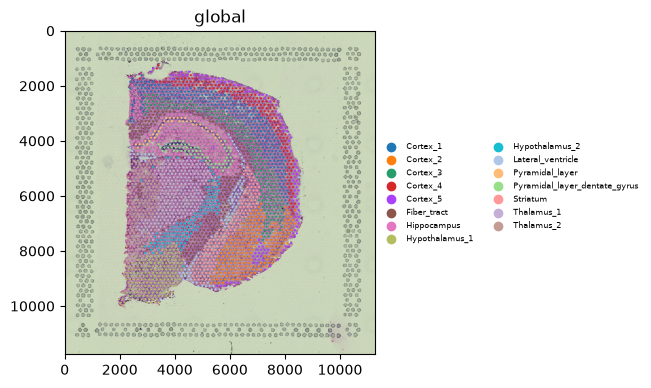

In [2]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
).pl.show(legend_fontsize=6)

## 2. Placing and restyling the legend

`legend_loc` takes any matplotlib location (`"upper left"`, …) or a margin
(`"right margin"`, `"left margin"`, `"top margin"`, `"bottom margin"`). `legend_fontsize`,
`legend_fontweight`, and `legend_fontoutline` (a contrasting outline around the text) style it.

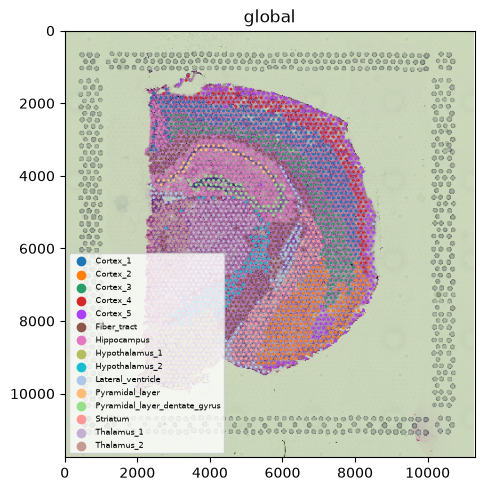

In [3]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
).pl.show(
    legend_loc="lower left",
    legend_fontsize=6,
    legend_fontweight="bold",
    legend_fontoutline=2,
)

## 3. Titles and hiding NA — `legend_title`, `na_in_legend`

`legend_title` names the legend. When you restrict to a few `groups`, the remaining spots become NA;
`na_in_legend=False` drops that entry from the key.

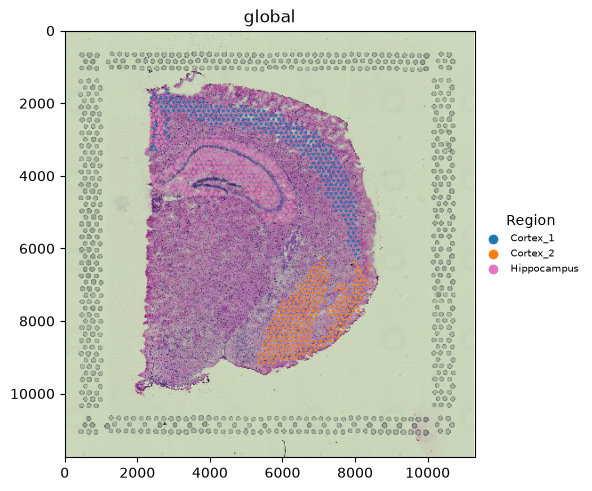

In [4]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster", groups=["Cortex_1", "Cortex_2", "Hippocampus"])
).pl.show(
    legend_title="Region",
    na_in_legend=False,
    legend_fontsize=7,
)

## 4. Bundling options — `legend_params`

Instead of the flat `legend_*` kwargs you can pass one `legend_params` dict. Accepted keys:
`location` (or `loc`), `fontsize`, `fontweight`, `fontoutline`, `na_in_legend`; it overrides the
matching flat kwargs, and unknown keys raise an error.

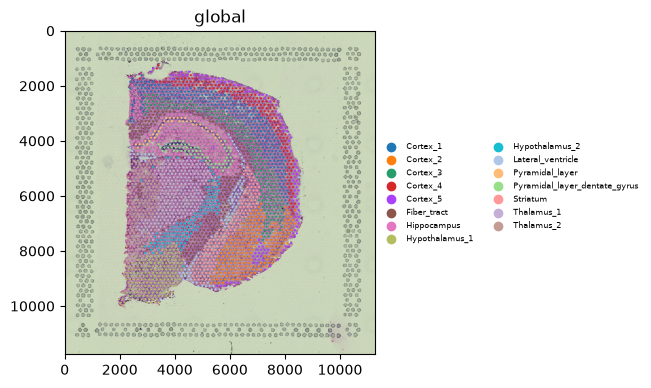

In [5]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
).pl.show(
    legend_params={"loc": "right margin", "fontsize": 6, "fontweight": "bold"},
)

## 5. Continuous colours get a colorbar

Colouring by a continuous column draws a **colorbar** instead of a legend. Here, total counts per
spot. `colorbar=True` is the default; pass `colorbar=False` to suppress it.

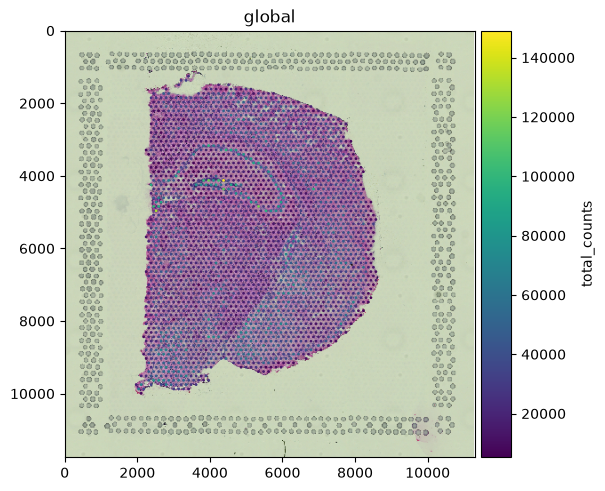

In [6]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="total_counts")
).pl.show()

## 6. Styling the colorbar — `colorbar_params`

`colorbar_params` accepts `label`, `loc`, `width`, `pad` (and matplotlib colorbar keys such as
`orientation`). Give the bar a label and move it below the plot.

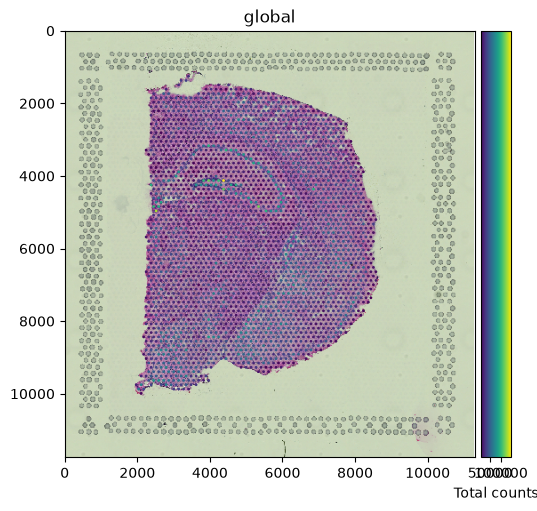

In [7]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="total_counts")
).pl.show(
    colorbar_params={"label": "Total counts", "orientation": "horizontal"},
)

## 7. A legend and a colorbar together

Passing a list to `color=` renders one panel per colouring (see the *Multi-panel colouring*
tutorial). Each panel gets the right key: a legend for the categorical panel, a colorbar for the
continuous one.

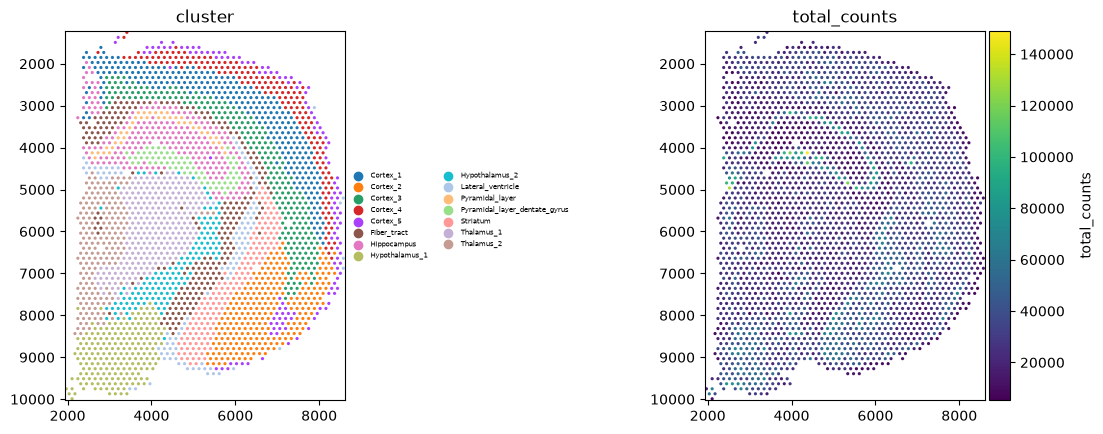

In [8]:
(
    sdata.pl.render_shapes("spots", color=["cluster", "total_counts"])
).pl.show(ncols=2, legend_fontsize=5)

## Summary

- Categorical colours draw a **legend**; continuous colours draw a **colorbar** — automatically.
- Place and style the legend with `legend_loc` (matplotlib locations or `"* margin"`),
  `legend_fontsize`/`fontweight`/`fontoutline`, `legend_title`, and `na_in_legend`; or bundle them in
  `legend_params`.
- Toggle the colorbar with `colorbar=` and style it with `colorbar_params` (`label`, `loc`, `width`,
  `pad`, `orientation`).
- In a multi-panel `color=[...]` figure each panel gets the appropriate key.

## For reproducibility

In [9]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.2
matplotlib      : 3.11.0
numpy           : 2.4.6

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

